In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import zipfile

zip_path = '/content/drive/MyDrive/Datasets/garbage_classification.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted")

Dataset extracted


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import os

In [ ]:
base_dir = '/content/dataset/garbage_classification'
classes = os.listdir(base_dir)
print(classes)

['battery', 'biological', 'trash', 'shoes', 'brown-glass', 'cardboard', 'plastic', 'metal', 'clothes', 'green-glass', 'white-glass', 'paper']


In [ ]:
total_images = 0
for cls in classes:
    path = os.path.join(base_dir, cls)
    count = len(os.listdir(path))
    print(f'{cls}: {count}')
    total_images += count

print('Total Images:', total_images)

battery: 945
biological: 985
trash: 697
shoes: 1977
brown-glass: 607
cardboard: 891
plastic: 865
metal: 769
clothes: 5325
green-glass: 629
white-glass: 775
paper: 1050
Total Images: 15515


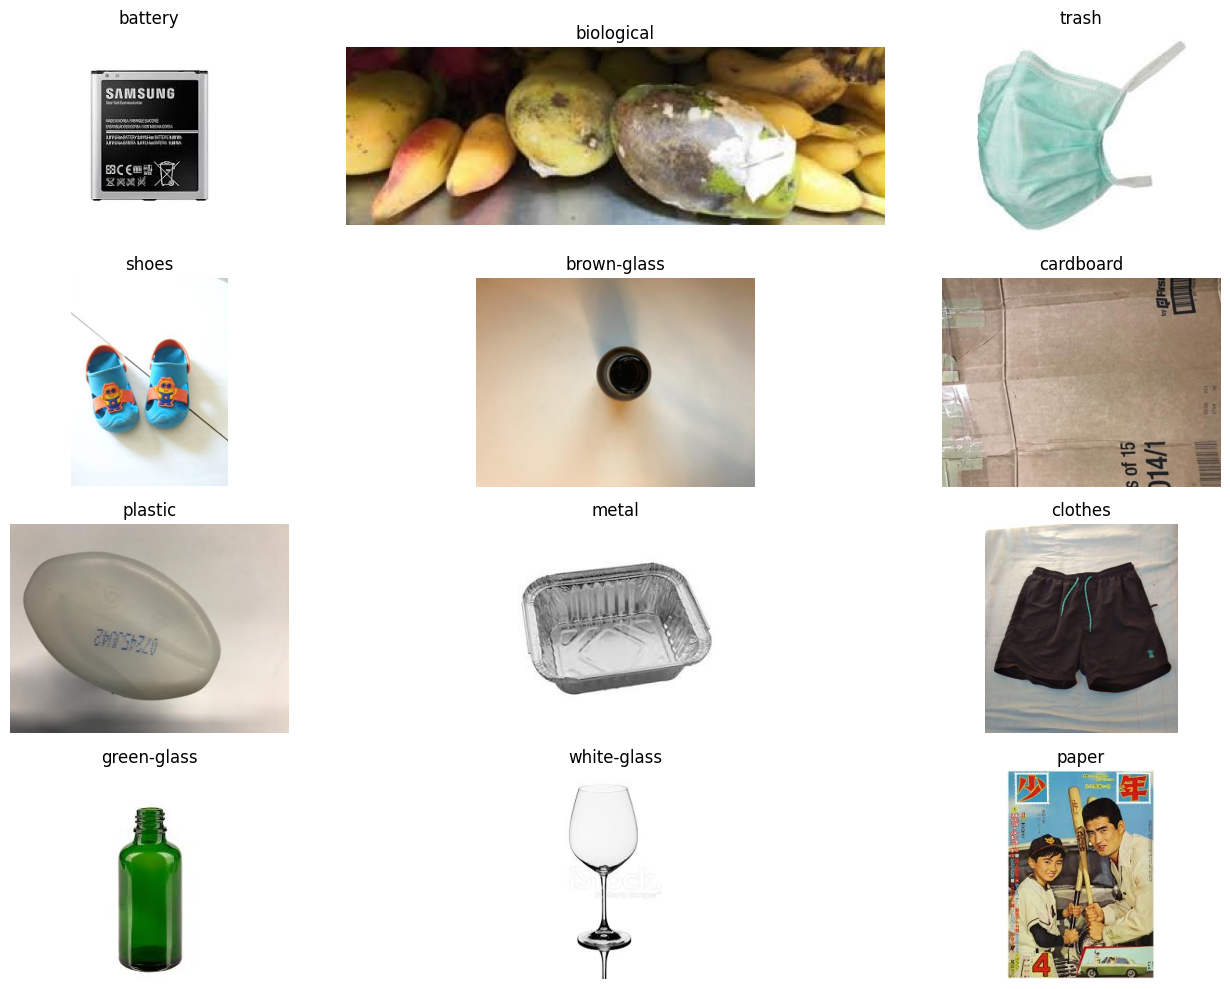

In [ ]:
plt.figure(figsize=(15,10))

for i, cls in enumerate(classes):
    img_path = os.path.join(base_dir, cls, os.listdir(os.path.join(base_dir, cls))[0])
    img = plt.imread(img_path)

    plt.subplot(4,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset= 'training',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    base_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 12415 images belonging to 12 classes.
Found 3100 images belonging to 12 classes.


In [ ]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

In [ ]:
print(train_generator.class_indices)
print(class_weights)

{'battery': 0, 'biological': 1, 'brown-glass': 2, 'cardboard': 3, 'clothes': 4, 'green-glass': 5, 'metal': 6, 'paper': 7, 'plastic': 8, 'shoes': 9, 'trash': 10, 'white-glass': 11}
{0: np.float64(1.3684964726631392), 1: np.float64(1.3129230118443316), 2: np.float64(2.128772290809328), 3: np.float64(1.451028517999065), 4: np.float64(0.24285993740219092), 5: np.float64(2.052744708994709), 6: np.float64(1.6795183982683983), 7: np.float64(1.2316468253968254), 8: np.float64(1.4950626204238922), 9: np.float64(0.6539717656974294), 10: np.float64(1.8540919952210275), 11: np.float64(1.6686827956989247)}


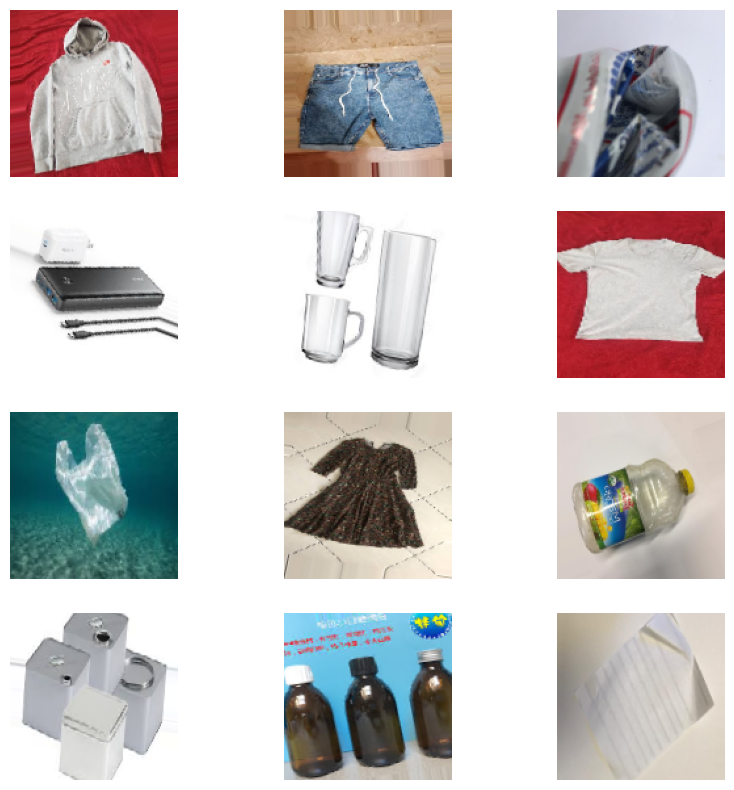

In [ ]:
sample_images, _ = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(12):
    plt.subplot(4,3,i+1)
    plt.imshow(sample_images[i])
    plt.axis('off')

plt.show()

In [ ]:
baseline_model = Sequential([

    Input(shape=(128, 128, 3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    Dense(len(classes), activation='softmax')
])

In [ ]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,557,964 (25.02 MB)

 Trainable params: 6,557,964 (25.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_baseline = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 607s 2s/step - accuracy: 0.5094 - loss: 1.4809 - val_accuracy: 0.5623 - val_loss: 1.2940
Epoch 2/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 547s 1s/step - accuracy: 0.6474 - loss: 1.0569 - val_accuracy: 0.6474 - val_loss: 1.0899
Epoch 3/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 510s 1s/step - accuracy: 0.7031 - loss: 0.9052 - val_accuracy: 0.6681 - val_loss: 1.0423
Epoch 4/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 510s 1s/step - accuracy: 0.7360 - loss: 0.8002 - val_accuracy: 0.6997 - val_loss: 0.9386
Epoch 5/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 551s 1s/step - accuracy: 0.7511 - loss: 0.7478 - val_accuracy: 0.6958 - val_loss: 0.9575
Epoch 6/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 549s 1s/step - accuracy: 0.7733 - loss: 0.6855 - val_accuracy: 0.7406 - val_loss: 0.8260
Epoch 7/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 551s 1s/step - accuracy: 0.7946 - loss: 0.6326 - val_accuracy: 0.7219 - val_loss: 0.8496
Epoch 8/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 560s 1s/step - accuracy: 0.8035 - loss: 0.5905 - val_accu

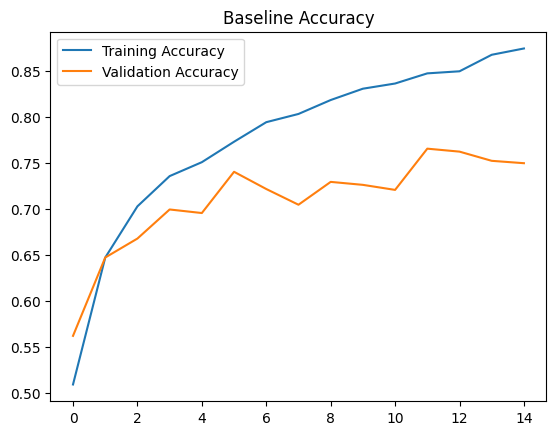

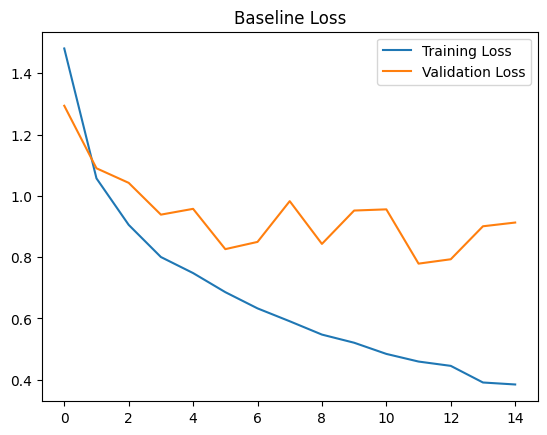

In [ ]:
plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Baseline Accuracy')
plt.show()

plt.plot(history_baseline.history['loss'], label='Training Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Baseline Loss')
plt.show()

In [ ]:
loss, accuracy = baseline_model.evaluate(val_generator)
print('Validation Accuracy:', accuracy)

97/97 ━━━━━━━━━━━━━━━━━━━━ 36s 368ms/step - accuracy: 0.7500 - loss: 0.9128
Validation Accuracy: 0.75


In [ ]:
predictions = baseline_model.predict(val_generator)
pred_classes = np.argmax(predictions, axis=1)

true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

print(classification_report(true_classes, pred_classes, target_names=class_labels))

97/97 ━━━━━━━━━━━━━━━━━━━━ 36s 370ms/step
              precision    recall  f1-score   support

     battery       0.75      0.54      0.63       189
  biological       0.78      0.71      0.74       197
 brown-glass       0.88      0.65      0.75       121
   cardboard       0.80      0.61      0.69       178
     clothes       0.88      0.95      0.92      1065
 green-glass       0.90      0.65      0.75       125
       metal       0.45      0.42      0.43       153
       paper       0.56      0.87      0.68       210
     plastic       0.52      0.69      0.59       173
       shoes       0.71      0.73      0.72       395
       trash       0.86      0.48      0.62       139
 white-glass       0.57      0.49      0.53       155

    accuracy                           0.75      3100
   macro avg       0.72      0.65      0.67      3100
weighted avg       0.76      0.75      0.75      3100



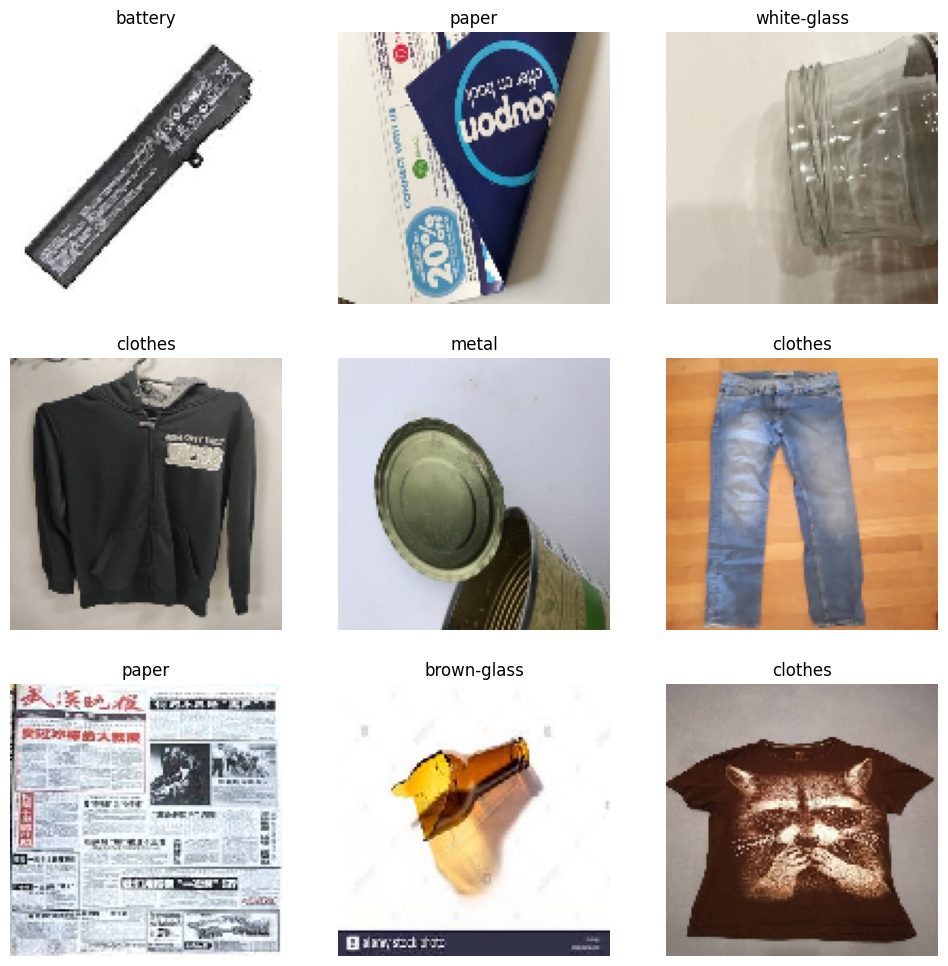

In [ ]:
images = []
labels = []

for i in range(len(val_generator)):
    x, y = val_generator[i]
    images.append(x)
    labels.append(y)

images = np.concatenate(images)
labels = np.concatenate(labels)

random_idx = np.random.choice(len(images), 9, replace=False)

plt.figure(figsize=(12,12))

for i, j in enumerate(random_idx):
    plt.subplot(3,3,i+1)
    plt.imshow(images[j])
    plt.title(class_labels[np.argmax(labels[j])])
    plt.axis('off')

plt.show()

In [ ]:
deeper_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(512, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),

    Dense(len(classes), activation='softmax')
])

In [ ]:
deeper_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_deep = deeper_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

Epoch 1/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 946s 2s/step - accuracy: 0.4224 - loss: 1.8656 - val_accuracy: 0.3377 - val_loss: 2.0541
Epoch 2/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 953s 2s/step - accuracy: 0.5329 - loss: 1.4279 - val_accuracy: 0.5874 - val_loss: 1.2628
Epoch 3/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 918s 2s/step - accuracy: 0.5832 - loss: 1.2976 - val_accuracy: 0.6400 - val_loss: 1.1525
Epoch 4/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 950s 2s/step - accuracy: 0.6183 - loss: 1.1932 - val_accuracy: 0.6432 - val_loss: 1.1066
Epoch 5/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 950s 2s/step - accuracy: 0.6416 - loss: 1.1192 - val_accuracy: 0.6703 - val_loss: 1.0377
Epoch 6/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 912s 2s/step - accuracy: 0.6569 - loss: 1.0619 - val_accuracy: 0.6474 - val_loss: 1.0612
Epoch 7/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 918s 2s/step - accuracy: 0.6725 - loss: 1.0071 - val_accuracy: 0.6726 - val_loss: 0.9833
Epoch 8/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 917s 2s/step - accuracy: 0.6946 - loss: 0.9544 - val_accu

In [ ]:
sgd_model = tf.keras.models.clone_model(deeper_model)

sgd_model.compile(
    optimizer=SGD(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = sgd_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [ ]:
base_model.trainable = False

In [ ]:
transfer_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

In [ ]:
train_generator_transfer = train_datagen.flow_from_directory(
    base_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator_transfer = val_datagen.flow_from_directory(
    base_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

In [ ]:
transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_transfer = transfer_model.fit(
    train_generator_transfer,
    validation_data=val_generator_transfer,
    epochs=10
)

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

In [ ]:
transfer_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_finetune = transfer_model.fit(
    train_generator_transfer,
    validation_data=val_generator_transfer,
    epochs=5
)